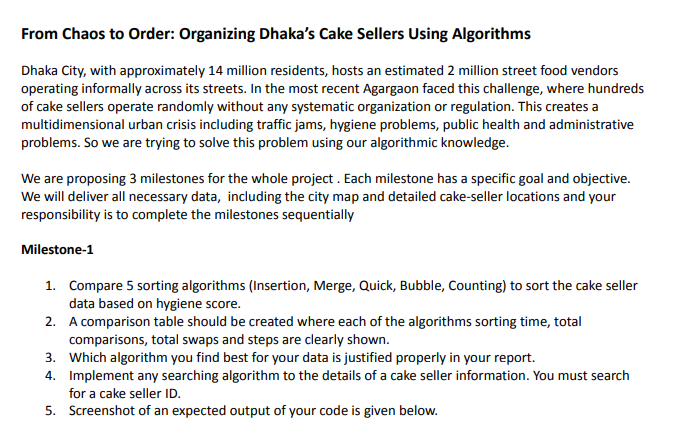
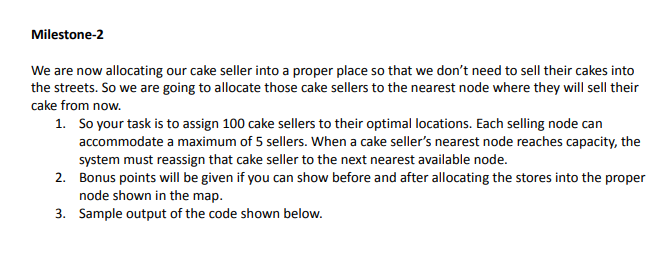
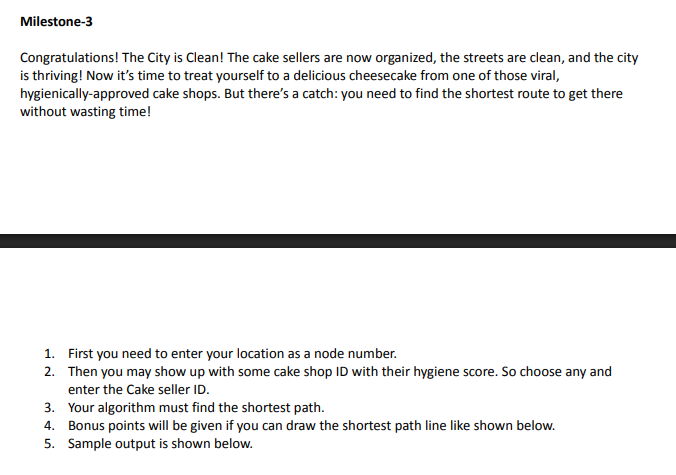

# Data Generation

**No need to change anything here in this section**

Understand the structure of the data and also you might get some hint from this part of code.

**Best of luck**

   DHAKA CAKE SELLER MANAGEMENT SYSTEM  

Initializing system... Generating cake seller data...
Generated 100 cake sellers at random locations
Loaded city road network with 15 nodes

SAMPLE CAKE SELLER DATA (First 10)

 1. CAKE-001 - Hygiene:  80/100 | Experience:  4 yrs | Revenue: ৳16,639
    Location: (23.8097, 90.3598)

 2. CAKE-002 - Hygiene:  48/100 | Experience:  4 yrs | Revenue: ৳59,348
    Location: (23.8096, 90.3718)

 3. CAKE-003 - Hygiene:  77/100 | Experience: 14 yrs | Revenue: ৳17,082
    Location: (23.7812, 90.3587)

 4. CAKE-004 - Hygiene:  72/100 | Experience: 20 yrs | Revenue: ৳16,739
    Location: (23.8024, 90.3786)

 5. CAKE-005 - Hygiene:  84/100 | Experience: 18 yrs | Revenue: ৳42,493
    Location: (23.7888, 90.3736)

 6. CAKE-006 - Hygiene:  91/100 | Experience:  1 yrs | Revenue: ৳25,463
    Location: (23.8079, 90.3636)

 7. CAKE-007 - Hygiene:  49/100 | Experience:  7 yrs | Revenue: ৳37,059
    Location: (23.7841, 90.3652)

 8. CAKE-008 - Hygiene:  62/100 | Exper

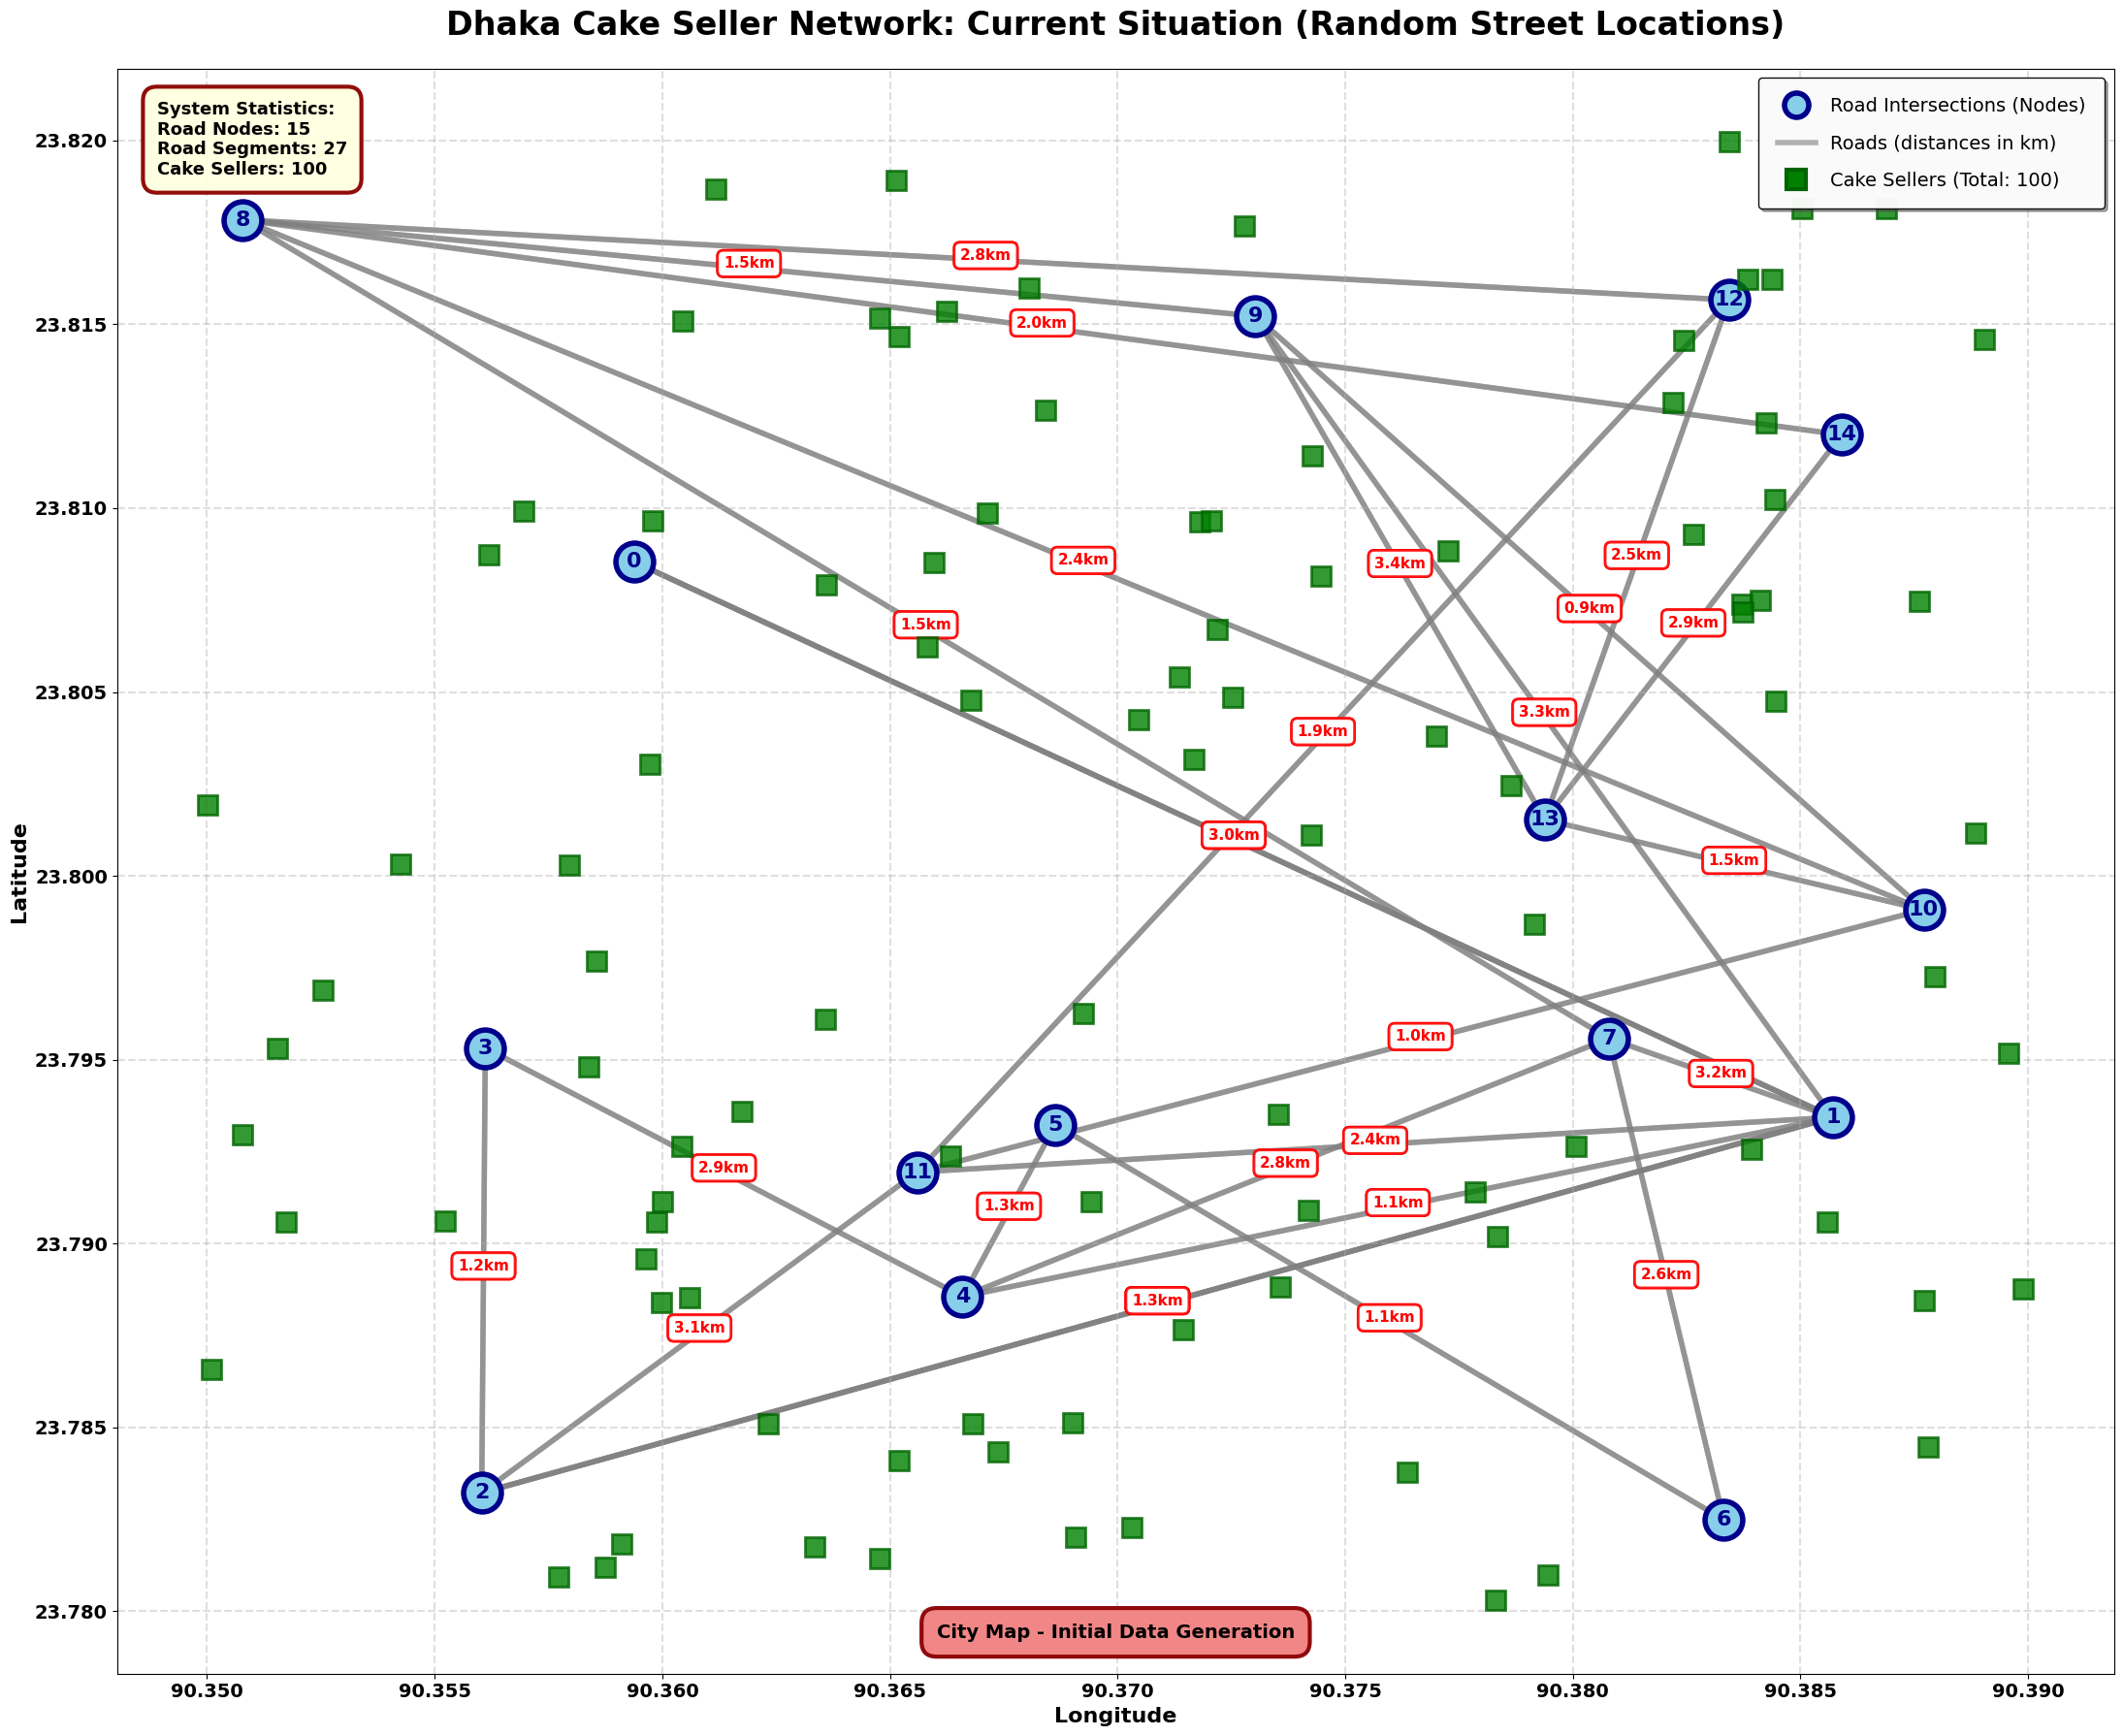

  Map window opened

DATA GENERATION COMPLETE!

Data Summary:
Generated 100 cake sellers at random street locations
Created road network with 15 nodes and 27 edges
Generated map visualization showing all data points

Data is ready for your project:
• Milestone 1: Sorting and Searching algorithms
• Milestone 2: Zone allocation with capacity constraints for the cake seller
• Milestone 3: Shortest path finder


In [ ]:
import random
import math
import heapq
import matplotlib.pyplot as plt


random.seed(42)


# ==================== DATA GENERATION ====================


def generate_vendor_data(num_vendors=50):
    """Generate random CAKE SELLER data only"""
    vendors = []

    for i in range(1, num_vendors + 1):
        vendor = {
            'id': f'CAKE-{i:03d}',
            'hygiene_score': random.randint(40, 100),
            'experience_years': random.randint(1, 20),
            'monthly_revenue': random.randint(15000, 60000),
            'location': (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39)),
            'type': 'Cake Seller'
        }
        vendors.append(vendor)

    return vendors



def generate_city_graph(num_nodes=15):
    """Generate a weighted graph representing Dhaka's road network"""
    graph = {i: [] for i in range(num_nodes)}

    for i in range(num_nodes - 1):
        weight = random.uniform(0.5, 3.0)
        graph[i].append((i + 1, weight))
        graph[i + 1].append((i, weight))

        if i > 0 and random.random() > 0.5:
            target = random.randint(0, i - 1)
            weight = random.uniform(1.0, 4.0)
            graph[i].append((target, weight))
            graph[target].append((i, weight))

    for _ in range(num_nodes // 2):
        node1 = random.randint(0, num_nodes - 1)
        node2 = random.randint(0, num_nodes - 1)
        if node1 != node2:
            weight = random.uniform(0.8, 3.5)
            edge_exists = False
            for neighbor, _ in graph[node1]:
                if neighbor == node2:
                    edge_exists = True
                    break
            if not edge_exists:
                graph[node1].append((node2, weight))
                graph[node2].append((node1, weight))

    return graph


def generate_node_coordinates(num_nodes=15):
    """Generate 2D coordinates for graph nodes"""
    coordinates = {}
    for i in range(num_nodes):
        coordinates[i] = (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39))
    return coordinates



def visualize_cake_sellers_network(city_graph, node_coordinates, vendors):
    """Create visualization with cake sellers and road network"""

    print("Creating cake seller network visualization...")

    fig, ax = plt.subplots(figsize=(22, 18))

    # Plot edges (roads) - BOLD GRAY LINES
    print("  Drawing roads...")
    for node, neighbors in city_graph.items():
        x1, y1 = node_coordinates[node][1], node_coordinates[node][0]
        for neighbor, weight in neighbors:
            x2, y2 = node_coordinates[neighbor][1], node_coordinates[neighbor][0]
            plt.plot([x1, x2], [y1, y2], 'gray', linewidth=4, alpha=0.6, zorder=1)

            # Add BOLD distance label on roads
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            plt.text(mid_x, mid_y, f'{weight:.1f}km', fontsize=11,
                    color='red', ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                             alpha=0.85, edgecolor='red', linewidth=2))

    # Plot nodes (intersections) - LARGER AND BOLDER
    print("  Drawing intersections...")
    for node, coord in node_coordinates.items():
        plt.plot(coord[1], coord[0], 'o', markersize=28,
                color='skyblue', markeredgecolor='darkblue',
                markeredgewidth=4, zorder=3)
        plt.text(coord[1], coord[0], str(node), fontsize=16,
                ha='center', va='center', fontweight='bold',
                color='darkblue', zorder=4)

    # Plot ALL CAKE SELLERS (no mapping lines, just points)
    print("  Drawing cake seller locations...")
    for v in vendors:
        plt.plot(v['location'][1], v['location'][0], 's',
                markersize=15, color='green', markeredgecolor='darkgreen',
                markeredgewidth=2, zorder=5, alpha=0.8)

    # Create legend with BOLD styling
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue',
               markersize=18, markeredgecolor='darkblue', markeredgewidth=4,
               label='Road Intersections (Nodes)', linewidth=0),
        Line2D([0], [0], color='gray', linewidth=4, alpha=0.6,
               label='Roads (distances in km)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='green',
               markersize=15, markeredgecolor='darkgreen', markeredgewidth=3,
               label=f'Cake Sellers (Total: {len(vendors)})', linewidth=0),
    ]

    plt.legend(handles=legend_elements, loc='upper right', fontsize=14,
              framealpha=0.95, edgecolor='black', fancybox=True,
              shadow=True, borderpad=1, labelspacing=1)

    # Add BOLD title and labels with SIZE 16 for axes
    plt.title('Dhaka Cake Seller Network: Current Situation (Random Street Locations)',
             fontsize=24, fontweight='bold', pad=25)

    # X and Y axis labels - BOLD SIZE 16
    plt.xlabel('Longitude', fontsize=16, fontweight='bold')
    plt.ylabel('Latitude', fontsize=16, fontweight='bold')

    # Make axis tick labels BOLD and larger
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

    # Add statistics box with BOLD text
    stats_text = 'System Statistics:\n'
    stats_text += f'Road Nodes: {len(city_graph)}\n'
    total_edges = sum(len(neighbors) for neighbors in city_graph.values()) // 2
    stats_text += f'Road Segments: {total_edges}\n'
    stats_text += f'Cake Sellers: {len(vendors)}'

    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=13, verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow',
                     alpha=0.95, edgecolor='darkred', linewidth=3))

    # Add City Map label at bottom
    plt.text(0.5, 0.02, "City Map - Initial Data Generation", transform=ax.transAxes,
            fontsize=14, ha='center', verticalalignment='bottom', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcoral',
                     alpha=0.95, edgecolor='darkred', linewidth=3))

    plt.tight_layout()

    # Save the figure
    filename = 'cake_sellers_data_visualization.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    try:
        plt.show()
        print("  Map window opened")
    except:
        print("  (File saved successfully)")

    plt.close()
    print()

# ==================== MAIN EXECUTION FOR DATA GENERATION AND VISUALIZATION ====================


print("="*70)
print("   DHAKA CAKE SELLER MANAGEMENT SYSTEM  ")
print("="*70)
print()

# Generate data
print("Initializing system... Generating cake seller data...")
vendors = generate_vendor_data(100)  # 100 cake sellers
city_graph = generate_city_graph(15)  # 15 road nodes
node_coordinates = generate_node_coordinates(15)


print(f"Generated {len(vendors)} cake sellers at random locations")
print(f"Loaded city road network with {len(city_graph)} nodes")
print()


# Show cake seller details
print("="*70)
print("SAMPLE CAKE SELLER DATA (First 10)")
print("="*70)
print()


for i, v in enumerate(vendors[:10], 1):
    print(f"{i:2d}. {v['id']} - Hygiene: {v['hygiene_score']:3d}/100 | "
          f"Experience: {v['experience_years']:2d} yrs | Revenue: ৳{v['monthly_revenue']:,}")
    print(f"    Location: ({v['location'][0]:.4f}, {v['location'][1]:.4f})")
    print()


# Show node coordinates
print("="*70)
print("NODE COORDINATES (First 5 Nodes)")
print("="*70)
print()


for node_id in range(5):
    lat, lon = node_coordinates[node_id]
    print(f"Node {node_id}:")
    print(f"  Latitude:  {lat:.6f}")
    print(f"  Longitude: {lon:.6f}")
    print(f"  GPS: ({lat:.4f}, {lon:.4f})")
    print()


# Visualize the network
print("="*70)
print("NETWORK VISUALIZATION")
print("="*70)
print()


visualize_cake_sellers_network(city_graph, node_coordinates, vendors)


# Final summary
print("="*70)
print("DATA GENERATION COMPLETE!")
print("="*70)
print(f"\nData Summary:")
print(f"Generated {len(vendors)} cake sellers at random street locations")
print(f"Created road network with {len(city_graph)} nodes and {sum(len(neighbors) for neighbors in city_graph.values()) // 2} edges")
print(f"Generated map visualization showing all data points")
print()
print("Data is ready for your project:")
print("• Milestone 1: Sorting and Searching algorithms")
print("• Milestone 2: Zone allocation with capacity constraints for the cake seller")
print("• Milestone 3: Shortest path finder")
print("="*70)


#**MUST RUN IT**

In [ ]:
import pandas as pd
import time
import math
import random
import heapq
import matplotlib.pyplot as plt


# Milestone-1

In [ ]:
def insertion_sort(data):
    n = len(data)
    arr = list(data)
    comparisons = 0
    swaps = 0
    steps = 0
    start_time = time.time()
    for i in range(1, n):
        key = arr[i]
        j = i - 1
        steps += 1
        while j >= 0:
            comparisons += 1
            steps += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]
                swaps += 1
                steps += 1
                j -= 1
            else:
                break
        arr[j + 1] = key
        steps += 1
    end_time = time.time()
    return arr, (end_time - start_time), comparisons, swaps, steps

def merge_sort(data):
    arr = list(data)
    comparisons = 0
    steps = 0
    start_time = time.time()

    def _merge_sort_recursive(temp_arr):
        nonlocal comparisons, steps
        if len(temp_arr) > 1:
            mid = len(temp_arr) // 2
            L = temp_arr[:mid]
            R = temp_arr[mid:]

            _merge_sort_recursive(L)
            _merge_sort_recursive(R)

            i = j = k = 0
            while i < len(L) and j < len(R):
                comparisons += 1
                steps += 1
                if L[i] <= R[j]:
                    temp_arr[k] = L[i]
                    i += 1
                else:
                    temp_arr[k] = R[j]
                    j += 1
                k += 1

            while i < len(L):
                temp_arr[k] = L[i]
                i += 1
                k += 1
                steps += 1
            while j < len(R):
                temp_arr[k] = R[j]
                j += 1
                k += 1
                steps += 1

    _merge_sort_recursive(arr)
    end_time = time.time()
    return arr, (end_time - start_time), comparisons, steps

def quick_sort(data):
    arr = list(data)
    comparisons = 0
    swaps = 0
    steps = 0
    start_time = time.time()

    def _partition(low, high):
        nonlocal comparisons, swaps, steps
        pivot = arr[high]
        i = low - 1
        steps += 1
        for j in range(low, high):
            comparisons += 1
            steps += 1
            if arr[j] <= pivot:
                i += 1
                arr[i], arr[j] = arr[j], arr[i]
                swaps += 1
                steps += 1
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        swaps += 1
        steps += 1
        return i + 1

    def _quick_sort(low, high):
        nonlocal steps
        if low < high:
            steps += 1
            pi = _partition(low, high)
            _quick_sort(low, pi - 1)
            _quick_sort(pi + 1, high)

    _quick_sort(0, len(arr) - 1)
    end_time = time.time()
    return arr, (end_time - start_time), comparisons, swaps, steps

def bubble_sort(data):
    n = len(data)
    arr = list(data)
    comparisons = 0
    swaps = 0
    steps = 0
    start_time = time.time()

    for i in range(n - 1):
        swapped = False
        steps += 1
        for j in range(0, n - i - 1):
            comparisons += 1
            steps += 1
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swaps += 1
                swapped = True
                steps += 1
        if not swapped:
            break
    end_time = time.time()
    return arr, (end_time - start_time), comparisons, swaps, steps

def counting_sort(data):
    arr = list(data)
    comparisons = 0
    steps = 0
    start_time = time.time()
    if not arr:
        return arr, 0, 0, 0

    max_val = max(arr)
    steps += len(arr)

    count = [0] * (max_val + 1)

    for x in arr:
        count[x] += 1
        steps += 1
    output = []
    for i in range(len(count)):
        while count[i] > 0:
            output.append(i)
            count[i] -= 1
            steps += 1

    end_time = time.time()
    return output, (end_time - start_time), 0, steps


def binary_search_seller_by_id(sorted_vendors, target_id):

    low = 0
    high = len(sorted_vendors) - 1
    steps = 0

    while low <= high:
        mid = (low + high) // 2
        mid_id = sorted_vendors[mid]['id']
        steps += 1

        if mid_id == target_id:
            return sorted_vendors[mid], steps
        elif mid_id < target_id:
            low = mid + 1
        else:
            high = mid - 1

    return None, steps

def run_milestone_1():
    print("\n" + "="*70)
    print("MILESTONE 1: SORTING & SEARCHING CAKE SELLERS")
    print("="*70)
    hygiene_scores = [v['hygiene_score'] for v in vendors]
    print(f"\n[PART A] SORTING ALGORITHMS COMPARISON")
    print(f"Sorting {len(hygiene_scores)} hygiene scores...")

    results = []

    #Insertion Sort
    _, t_ins, c_ins, s_ins, st_ins = insertion_sort(hygiene_scores)
    results.append(["Insertion Sort", f"{t_ins:.6f}", c_ins, s_ins, st_ins])

    #Merge Sort
    _, t_mrg, c_mrg, st_mrg = merge_sort(hygiene_scores)
    results.append(["Merge Sort", f"{t_mrg:.6f}", c_mrg, "N/A", st_mrg])

    #Quick Sort
    _, t_qui, c_qui, s_qui, st_qui = quick_sort(hygiene_scores)
    results.append(["Quick Sort", f"{t_qui:.6f}", c_qui, s_qui, st_qui])

    #Bubble Sort
    _, t_bub, c_bub, s_bub, st_bub = bubble_sort(hygiene_scores)
    results.append(["Bubble Sort", f"{t_bub:.6f}", c_bub, s_bub, st_bub])

    #Counting Sort
    _, t_cnt, c_cnt, st_cnt = counting_sort(hygiene_scores)
    results.append(["Counting Sort", f"{t_cnt:.6f}", 0, "N/A", st_cnt])

    # Display Comparison Table
    df = pd.DataFrame(results, columns=["Algorithm", "Time (s)", "Comparisons", "Swaps", "Steps"])
    print("\n" + df.to_markdown(index=False))



    # SEARCHING
    print("\n[PART B] SEARCHING FOR SELLER DETAILS")
    print("-" * 40)

    # Sort vendors by ID first
    vendors_sorted_by_id = sorted(vendors, key=lambda x: x['id'])
    print("Range of the seller ID (CAKE-001) to (CAKE-100)")
    target_search_id = input("Please Enter the Cake seller ID: ")
    print(f"Searching for ID: {target_search_id} using Binary Search...")

    found_seller, search_steps = binary_search_seller_by_id(vendors_sorted_by_id, target_search_id)

    if found_seller:
        print("\n✔ SELLER FOUND!")
        print(f"ID:       {found_seller['id']}")
        print(f"Hygiene:  {found_seller['hygiene_score']}/100")
        print(f"Experience: {found_seller['experience_years']} years")
        print(f"Monthly Revenue:  ৳{found_seller['monthly_revenue']}")
        print(f"Location: {found_seller['location']}")
        print(f"Type:     {found_seller['type']}")
        print(f"Search Steps Taken: {search_steps}")
    else:
        print("❌ Seller not found.")

# EXECUTE
run_milestone_1()


MILESTONE 1: SORTING & SEARCHING CAKE SELLERS

[PART A] SORTING ALGORITHMS COMPARISON
Sorting 100 hygiene scores...

| Algorithm      |   Time (s) |   Comparisons | Swaps   |   Steps |
|:---------------|-----------:|--------------:|:--------|--------:|
| Insertion Sort |   0.00085  |          2479 | 2383    |    5060 |
| Merge Sort     |   0.000372 |           535 | N/A     |     672 |
| Quick Sort     |   0.000211 |           682 | 407     |    1225 |
| Bubble Sort    |   0.005306 |          4922 | 2383    |    7397 |
| Counting Sort  |   5.6e-05  |             0 | N/A     |     300 |

[PART B] SEARCHING FOR SELLER DETAILS
----------------------------------------
Range of the seller ID (CAKE-001) to (CAKE-100)
Please Enter the Cake seller ID: CAKE-100
Searching for ID: CAKE-100 using Binary Search...

✔ SELLER FOUND!
ID:       CAKE-100
Hygiene:  60/100
Experience: 15 years
Monthly Revenue:  ৳43952
Location: (23.797686391972192, 90.35854805603957)
Type:     Cake Seller
Search Steps Ta

# Milestone-2

   DHAKA CAKE SELLER MANAGEMENT SYSTEM  

Initializing system... Generating cake seller data...
Generated 100 cake sellers at random locations
Loaded city road network with 15 nodes

SAMPLE CAKE SELLER DATA (First 10)

 1. CAKE-001 - Hygiene:  71/100 | Experience:  8 yrs | Revenue: ৳32,887
    Location: (23.7974, 90.3512)

 2. CAKE-002 - Hygiene:  61/100 | Experience: 13 yrs | Revenue: ৳25,816
    Location: (23.8136, 90.3868)

 3. CAKE-003 - Hygiene:  79/100 | Experience: 18 yrs | Revenue: ৳16,767
    Location: (23.8163, 90.3737)

 4. CAKE-004 - Hygiene:  82/100 | Experience:  1 yrs | Revenue: ৳20,501
    Location: (23.8057, 90.3554)

 5. CAKE-005 - Hygiene:  69/100 | Experience:  6 yrs | Revenue: ৳18,295
    Location: (23.7904, 90.3631)

 6. CAKE-006 - Hygiene:  69/100 | Experience: 11 yrs | Revenue: ৳37,118
    Location: (23.8104, 90.3652)

 7. CAKE-007 - Hygiene:  88/100 | Experience: 14 yrs | Revenue: ৳31,532
    Location: (23.8134, 90.3688)

 8. CAKE-008 - Hygiene:  87/100 | Exper

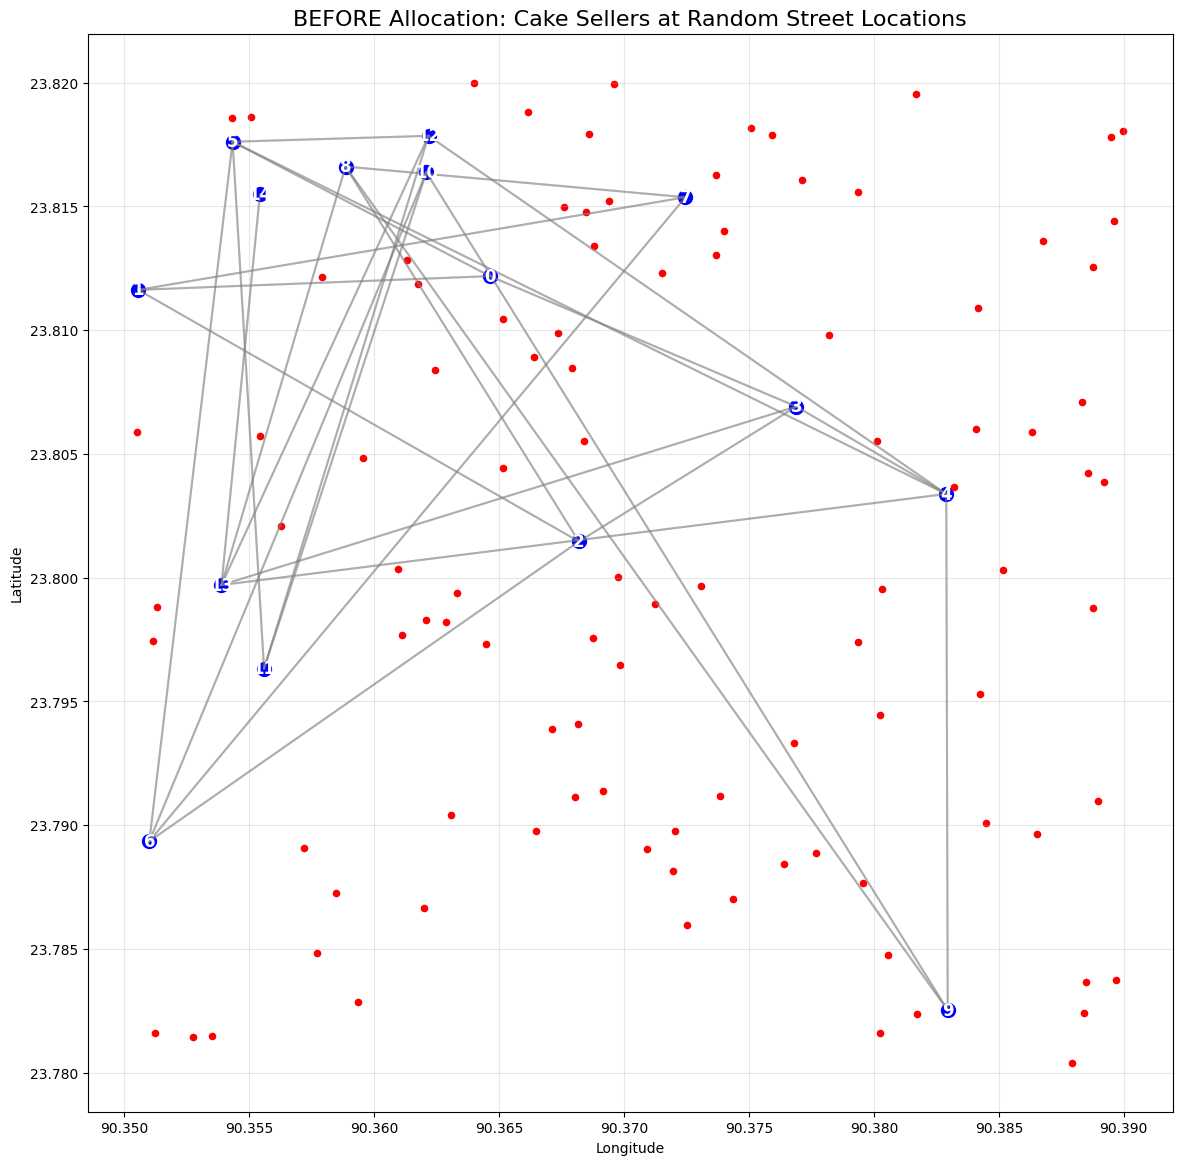

                     MILESTONE 2 : SELLER ALLOCATION

Total Cake Sellers      : 100
Total Nodes Available   : 15
Capacity Per Node       : 5
------------------------------------------------------
Total Node Capacity     : 75
Total Assigned Sellers  : 75
Total Waitlisted Sellers: 25
------------------------------------------------------

Assigned Seller Summary (First 15 shown)
----------------------------------------
Seller ID     Assigned Node     Distance (km)
------------------------------------------------------
CAKE-001      13               0.0035    
CAKE-002      4                0.011     
CAKE-003      7                0.0015    
CAKE-004      13               0.0062    
CAKE-005      11               0.0096    
CAKE-006      0                0.0018    
CAKE-007      7                0.0041    
CAKE-008      12               0.0028    
CAKE-009      6                0.0077    
CAKE-010      13               0.0076    
CAKE-011      7                0.0046    
CAKE-012      4 

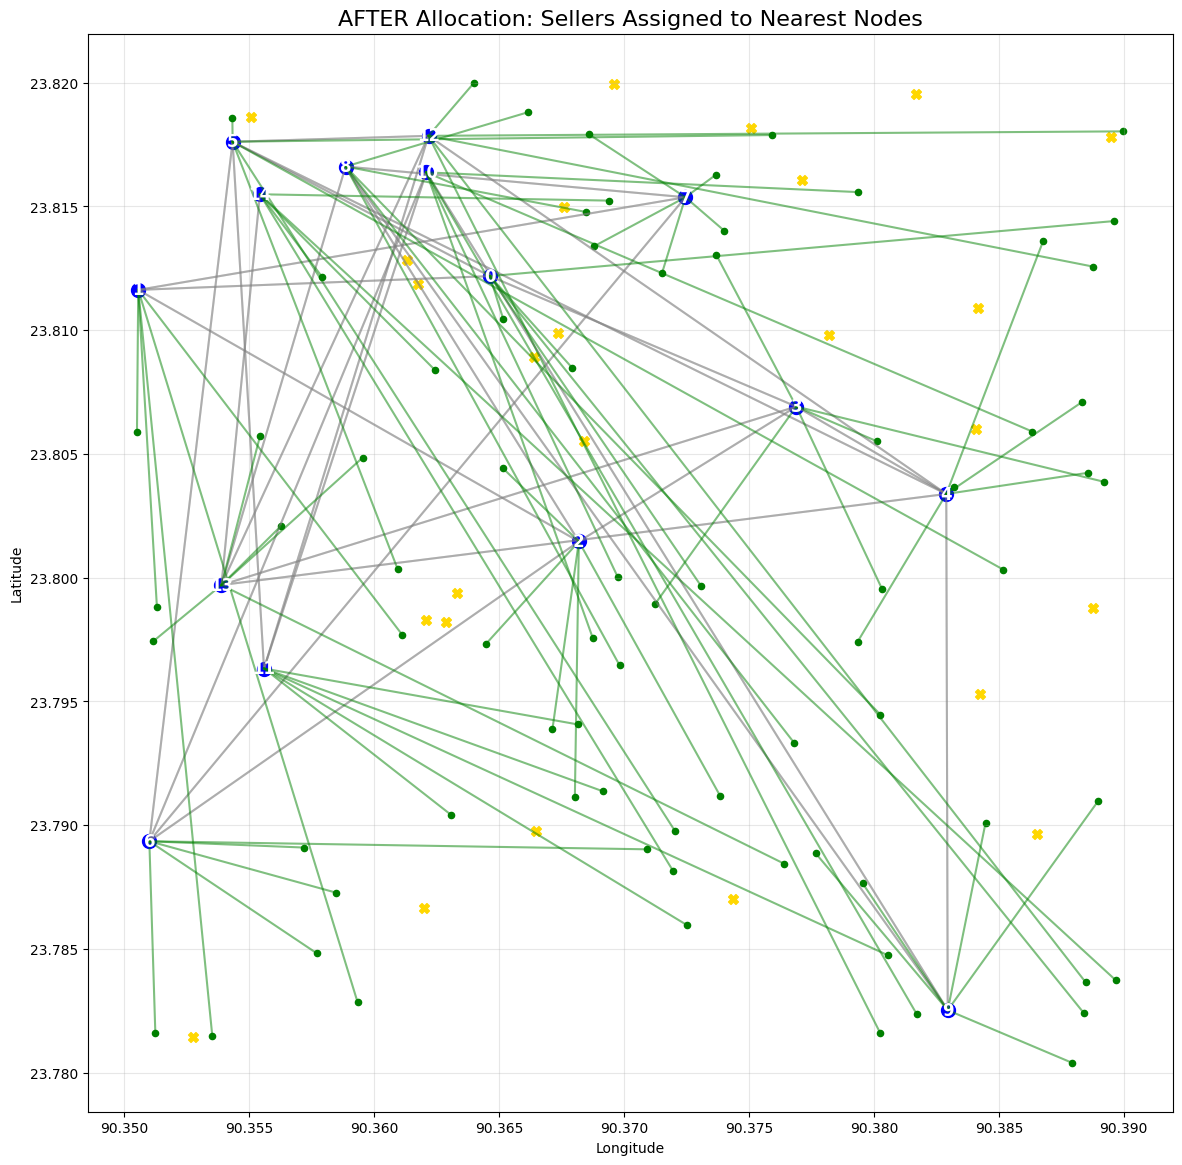

>>> Allocation Map BEFORE and AFTER has been generated.
>>> Milestone 2 complete.

DATA GENERATION + MILESTONE 2 COMPLETE!


In [ ]:
def euclidean_distance(seller_loc, node_loc):
    return math.sqrt(
        (seller_loc[0] - node_loc[0])**2 +
        (seller_loc[1] - node_loc[1])**2
    )


def assign_sellers_to_nodes(vendors, node_coordinates, capacity=5):
    node_capacity = {node_id: capacity for node_id in node_coordinates}
    assignments = []
    waitlist = []

    for seller in vendors:
        seller_loc = seller['location']
        heap = []
        for node_id, coord in node_coordinates.items():
            dist = euclidean_distance(seller_loc, coord)
            heapq.heappush(heap, (dist, node_id))

        assigned = False

        # Pick nearest available node
        while heap:
            dist, node_id = heapq.heappop(heap)

            if node_capacity[node_id] > 0:
                node_capacity[node_id] -= 1

                assignments.append({
                    'seller_id': seller['id'],
                    'node_id': node_id,
                    'distance': round(dist, 4),
                    'seller_location': seller['location'],
                    'node_location': node_coordinates[node_id]
                })

                assigned = True
                break

        # If all nodes full (waitlist)
        if not assigned:
            waitlist.append(seller['id'])

    return assignments, waitlist, node_capacity


def visualize_before_allocation(city_graph, node_coordinates, vendors):

    plt.figure(figsize=(14, 14))

    # Draw roads
    for node, neighbors in city_graph.items():
        x1, y1 = node_coordinates[node][1], node_coordinates[node][0]
        for neighbor, _ in neighbors:
            x2, y2 = node_coordinates[neighbor][1], node_coordinates[neighbor][0]
            plt.plot([x1, x2], [y1, y2], 'gray', alpha=0.4)

    # Draw nodes
    for node_id, coord in node_coordinates.items():
        plt.scatter(coord[1], coord[0], color='blue', s=100)
        plt.text(coord[1], coord[0], str(node_id), fontsize=12, fontweight='bold',
                 color='white', ha='center', va='center')

    # Draw sellers
    for v in vendors:
        plt.scatter(v['location'][1], v['location'][0], color='red', s=20)

    plt.title("BEFORE Allocation: Cake Sellers at Random Street Locations", fontsize=16)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.3)

    plt.show()


def visualize_after_allocation(city_graph, node_coordinates, assignments, waitlist, vendors):

    plt.figure(figsize=(14, 14))

    for node, neighbors in city_graph.items():
        x1, y1 = node_coordinates[node][1], node_coordinates[node][0]
        for neighbor, _ in neighbors:
            x2, y2 = node_coordinates[neighbor][1], node_coordinates[neighbor][0]
            plt.plot([x1, x2], [y1, y2], 'gray', alpha=0.4)

    for node_id, coord in node_coordinates.items():
        plt.scatter(coord[1], coord[0], color='blue', s=100)
        plt.text(coord[1], coord[0], str(node_id), fontsize=12, fontweight='bold',
                 color='white', ha='center', va='center')

    # Draw sellers and their assignments
    for a in assignments:
        seller_x = a['seller_location'][1]
        seller_y = a['seller_location'][0]
        node_x = a['node_location'][1]
        node_y = a['node_location'][0]

        plt.scatter(seller_x, seller_y, color='green', s=20)
        plt.plot([seller_x, node_x], [seller_y, node_y], 'green', alpha=0.5)

    # Plot waitlisted sellers in YELLOW
    for v in vendors:
        if v['id'] in waitlist:
            plt.scatter(v['location'][1], v['location'][0],
                        color='gold', s=50, marker='X')

    plt.title("AFTER Allocation: Sellers Assigned to Nearest Nodes", fontsize=16)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.3)

    plt.show()




#  EXECUTION
print("="*70)
print("   DHAKA CAKE SELLER MANAGEMENT SYSTEM  ")
print("="*70)
print()

#DATA GENERATION
print("Initializing system... Generating cake seller data...")
vendors = generate_vendor_data(100)
city_graph = generate_city_graph(15)
node_coordinates = generate_node_coordinates(15)

print(f"Generated {len(vendors)} cake sellers at random locations")
print(f"Loaded city road network with {len(city_graph)} nodes\n")


#DISPLAY SAMPLE DATA
print("="*70)
print("SAMPLE CAKE SELLER DATA (First 10)")
print("="*70)
print()

for i, v in enumerate(vendors[:10], 1):
    print(f"{i:2d}. {v['id']} - Hygiene: {v['hygiene_score']:3d}/100 | "
          f"Experience: {v['experience_years']:2d} yrs | Revenue: ৳{v['monthly_revenue']:,}")
    print(f"    Location: ({v['location'][0]:.4f}, {v['location'][1]:.4f})\n")


print("="*70)
print("NODE COORDINATES (First 5 Nodes)")
print("="*70)
print()

for node_id in range(5):
    lat, lon = node_coordinates[node_id]
    print(f"Node {node_id}: Latitude: {lat:.6f}, Longitude: {lon:.6f}")
    print(f"  GPS: ({lat:.4f}, {lon:.4f})\n")


#VISUALIZATION BEFORE ALLOCATION
print("="*70)
print("NETWORK VISUALIZATION (BEFORE ALLOCATION)")
print("="*70)
print()

visualize_before_allocation(city_graph, node_coordinates, vendors)

print("="*70)
print("                     MILESTONE 2 : SELLER ALLOCATION")
print("="*70)

assignments, waitlist, node_capacity = assign_sellers_to_nodes(vendors, node_coordinates)

total_capacity = len(node_capacity) * 5

print(f"\nTotal Cake Sellers      : {len(vendors)}")
print(f"Total Nodes Available   : {len(node_capacity)}")
print(f"Capacity Per Node       : 5")
print("-" * 54)
print(f"Total Node Capacity     : {total_capacity}")
print(f"Total Assigned Sellers  : {len(assignments)}")
print(f"Total Waitlisted Sellers: {len(waitlist)}")
print("-" * 54)


#ASSIGNMENT SUMMARY
print("\nAssigned Seller Summary (First 15 shown)")
print("----------------------------------------")
print("Seller ID     Assigned Node     Distance (km)")
print("-" * 54)

for a in assignments[:15]:
    print(f"{a['seller_id']:<13} {a['node_id']:<16} {a['distance']:<10}")

print("-" * 54)


#NODE CAPACITY STATUS
print("\nNode Capacity Status (After Allocation)")
print("----------------------------------------")
print("Node ID     Remaining Slots")
print("----------------------------")

for node_id, cap in node_capacity.items():
    print(f"{node_id:<13}{cap}")

print("\n" + "-"*54)


#WAITLIST SUMMARY
print(f"\nWAITLISTED SELLERS ({len(waitlist)})")
print("----------------------------------------")

if waitlist:
    print(", ".join(waitlist))
else:
    print("No sellers in waitlist.")

print("-" * 54)


#VISUALIZATION
print("\nGenerating AFTER ALLOCATION map...\n")

visualize_after_allocation(city_graph, node_coordinates, assignments, waitlist, vendors)

print(">>> Allocation Map BEFORE and AFTER has been generated.")
print(">>> Milestone 2 complete.\n")


print("="*70)
print("DATA GENERATION + MILESTONE 2 COMPLETE!")
print("="*70)


# Milestone-3

write your code for milestone-3

In [ ]:
class CityNavigator:
    def __init__(self, city_graph, node_coords, assignments, all_vendors):
        self.graph = city_graph
        self.coords = node_coords
        self.assignments = assignments
        self.seller_db = {}
        temp_hygiene = {v['id']: v['hygiene_score'] for v in all_vendors}

        # Map Assignments
        for item in assignments:
            s_id = item['seller_id']
            self.seller_db[s_id] = {
                'id': s_id,
                'node_id': item['node_id'],
                'hygiene': temp_hygiene.get(s_id, 0),
                'location': item['seller_location']
            }

    def dijkstra(self, start_node, end_node):

        # Priority Queue: (current_dist, current_node)
        pq = [(0, start_node)]
        distances = {node: float('inf') for node in self.graph}
        distances[start_node] = 0
        parent = {node: None for node in self.graph}

        while pq:
            curr_dist, curr_node = heapq.heappop(pq)

            if curr_node == end_node:
                break

            if curr_dist > distances[curr_node]:
                continue

            for neighbor, weight in self.graph[curr_node]:
                new_dist = curr_dist + weight
                if new_dist < distances[neighbor]:
                    distances[neighbor] = new_dist
                    parent[neighbor] = curr_node
                    heapq.heappush(pq, (new_dist, neighbor))

        # Reconstruct Path
        path = []
        if distances[end_node] == float('inf'):
            return -1, []

        curr = end_node
        while curr is not None:
            path.append(curr)
            curr = parent[curr]
        path.reverse()

        return distances[end_node], path

    def visualize_route_bonus(self, path, seller_id):

        print(f"\n[BONUS] Generatng Route Visualization for {seller_id}...")

        plt.figure(figsize=(12, 12))

        #Background Roads (Grey)
        for node, neighbors in self.graph.items():
            x1, y1 = self.coords[node][1], self.coords[node][0]
            for neighbor, _ in neighbors:
                x2, y2 = self.coords[neighbor][1], self.coords[neighbor][0]
                plt.plot([x1, x2], [y1, y2], 'lightgray', linewidth=2, zorder=1)

        # Nodes (Blue)
        for node, (lat, lon) in self.coords.items():
            plt.scatter(lon, lat, color='skyblue', s=100, zorder=2)
            plt.text(lon, lat, str(node), fontsize=9, ha='center', va='center', zorder=3)

        # THE SHORTEST PATH (Red Line)
        path_lons = [self.coords[n][1] for n in path]
        path_lats = [self.coords[n][0] for n in path]

        plt.plot(path_lons, path_lats, color='red', linewidth=4, alpha=0.8,
                 label='Shortest Path', zorder=4)

        #Highlight Start & End
        start_node = path[0]
        end_node = path[-1]

        plt.scatter(self.coords[start_node][1], self.coords[start_node][0],
                    color='blue', s=200, label='Start (You)', zorder=5, edgecolors='black')

        plt.scatter(self.coords[end_node][1], self.coords[end_node][0],
                    color='gold', s=250, marker='*', label=f'Destination ({seller_id})', zorder=5, edgecolors='black')

        plt.title(f"Milestone 3: Shortest Route to {seller_id}", fontsize=16, fontweight='bold')
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def run(self):
        print("\n" + "="*70)
        print("MILESTONE 3: SHORTEST PATH OPTIMIZATION")
        print("="*70)

        # Get User Location
        print(f"\nAvailable nodes: 0 to {len(self.graph)-1}")
        try:
            my_loc = int(input("Where are you currently located? (Enter Node Number): "))
            if my_loc not in self.graph: raise ValueError
        except ValueError:
            print("Invalid Node! Defaulting to Node 0.")
            my_loc = 0

        print(f"You are at Node {my_loc}")
        print(f"Coordinates: {self.coords[my_loc]}")

        #Get Target Seller

        print(f"\n--- Available Sellers (Top 5) ---")
        for i, sid in enumerate(list(self.seller_db.keys())[:5]):
            print(f"{sid} (at Node {self.seller_db[sid]['node_id']})")

        # Explicitly prompt the user for cake seller ID input
        print("\n======================================================")
        print("Please provide the Cake Seller ID you wish to visit.")
        print("======================================================")
        target_id = input("Enter Seller ID to visit (e.g., CAKE-005): ").strip()

        if target_id not in self.seller_db:
            print("❌ Seller ID not found or is in the Waitlist (not assigned to a node).")
            return

        target = self.seller_db[target_id]

        # Display Info
        print(f"\nFound: {target['id']}")
        print(f"Allocated to: Node {target['node_id']}")
        print(f"Hygiene Score: {target['hygiene']}/100")
        print("Calculating shortest route...")

        # Run Dijkstra
        if my_loc == target['node_id']:
            print("\nResult: You are already at the correct node!")
            return

        dist, path = self.dijkstra(my_loc, target['node_id'])

        if dist != -1:
            print("\n✔ SHORTEST ROUTE FOUND!")
            route_str = " -> ".join(map(str, path))
            print(f"Route: {route_str}")

            print("-" * 40)
            print("ROUTE DETAILS:")
            print(f"Start Node:      {my_loc}")
            print(f"End Node:        {target['node_id']} ({target['id']})")
            print(f"Number of Stops: {len(path)} nodes")
            print(f"Total Distance:  {dist:.4f} km")
            print("-" * 40)

            #Visualization
            self.visualize_route_bonus(path, target['id'])
        else:
            print("Error: No path exists between these nodes.")

#EXECUTE MILESTONE 3

app = CityNavigator(city_graph, node_coordinates, assignments, vendors)
app.run()


MILESTONE 3: SHORTEST PATH OPTIMIZATION

Available nodes: 0 to 14
Where are you currently located? (Enter Node Number): 4
You are at Node 4
Coordinates: (23.803382403666088, 90.38289669204907)

--- Available Sellers (Top 5) ---
CAKE-001 (at Node 13)
CAKE-002 (at Node 4)
CAKE-003 (at Node 7)
CAKE-004 (at Node 13)
CAKE-005 (at Node 11)

Please provide the Cake Seller ID you wish to visit.
Enter Seller ID to visit (e.g., CAKE-005): CAKE-33
❌ Seller ID not found or is in the Waitlist (not assigned to a node).
